# MediaPipe Skeleton Quality Evaluation

Notebook ini bertujuan untuk mengevaluasi kualitas *skeleton* (pose 3D) yang diekstrak oleh MediaPipe dari 507 video dataset (Squat, Bench Press, Deadlift). Karena kita tidak memiliki anotasi *Ground Truth* manual dari titik sendi untuk seluruh video, evaluasi dilakukan secara kuantitatif melalui dua metrik biomekanik *Unsupervised*:

1. **Visibility Score (Tingkat Kepercayaan Model)**: Rata-rata dari nilai `visibility` (skor 0-1) yang diberikan oleh MediaPipe untuk 12 titik sendi yang kita amati.
2. **Bone Length Jitter (Inkonsistensi Panjang Tulang)**: Mengukur deviasi standar dari jarak 3D antar sendi yang bersebelahan (contoh: Bahu ke Siku). Pada manusia nyata, jarak antar dua sendi ini bersifat konstan sepanjang video. Variasi ekstrem menandakan deteksi skeleton yang tidak stabil atau "ngaco" (stretching/shrinking bone phenomenon).

In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")

RAW_DATA_DIR = Path("../data/raw")

# 12 Titik Sendi Esensial yang kita gunakan (MediaPipe Indexing)
TARGET_JOINTS = {
    11: "Bahu_Kiri", 12: "Bahu_Kanan",
    13: "Siku_Kiri", 14: "Siku_Kanan",
    15: "Prg_Tgn_Kiri", 16: "Prg_Tgn_Kanan",
    23: "Pinggul_Kiri", 24: "Pinggul_Kanan",
    25: "Lutut_Kiri", 26: "Lutut_Kanan",
    27: "Prg_Kaki_Kiri", 28: "Prg_Kaki_Kanan"
}

# Definisi ruas tulang berdasarkan index MediaPipe
BONE_CONNECTIONS = {
    "Lengan_Atas_Kiri": (11, 13),
    "Lengan_Bawah_Kiri": (13, 15),
    "Lengan_Atas_Kanan": (12, 14),
    "Lengan_Bawah_Kanan": (14, 16),
    "Paha_Kiri": (23, 25),
    "Betis_Kiri": (25, 27),
    "Paha_Kanan": (24, 26),
    "Betis_Kanan": (26, 28),
}

## 1. Load Data & Hitung Metrik per Video
Karena data preprocessed (`.npy`) kita sebelumnya hanya menyimpan koordinat (X,Y,Z), kita akan menggunakan modul `extract_mediapipe_landmarks` untuk mengekstrak pose array (X,Y,Z,Visibility) secara langsung dari sebagian sampel (atau seluruh dataset) di folder `raw`.

In [2]:
import sys
import os
sys.path.append('..')
sys.path.append(os.path.abspath(os.path.join('..', 'src')))
from src.analysis.cvat_mediapipe_pilot import extract_mediapipe_landmarks

visibility_records = []
jitter_records = []

exercises = ["Squat", "BenchPress", "Deadlift"]
all_videos = list(RAW_DATA_DIR.rglob("*.mp4"))

# Untuk efisiensi demonstrasi komputasi di notebook ini, 
# kita akan mengambil maksimal 30 sampel acak per gerakan (total 90 video)
import random
random.seed(42)
sample_videos = []
for ex in exercises:
    ex_vids = list((RAW_DATA_DIR / ex).glob("*.mp4"))
    sample_videos.extend(random.sample(ex_vids, min(30, len(ex_vids))))

print(f"Memproses {len(sample_videos)} video untuk evaluasi kuantitatif...")

for vid_path in tqdm(sample_videos):
    exercise_name = vid_path.parent.name
    
    # Ekstrak MediaPipe Pose (bentuk: Frames, 33, 4)
    bundle = extract_mediapipe_landmarks(str(vid_path))
    if len(bundle.frames_bgr) == 0:
        continue
        
    pose_array = bundle.pose_array # (F, 33, 4)
    
    # --- 1. Rata-Rata Visibility Score ---
    # shape: (F, 12, 1) -> Mean over frames
    for joint_idx, joint_name in TARGET_JOINTS.items():
        mean_vis = np.nanmean(pose_array[:, joint_idx, 3])
        visibility_records.append({
            "Exercise": exercise_name,
            "Video": vid_path.name,
            "Joint": joint_name,
            "Mean_Visibility": mean_vis
        })
        
    # --- 2. Bone Length Jitter ---
    # Hitung panjang antar dua titik untuk setiap frame
    for bone_name, (idx1, idx2) in BONE_CONNECTIONS.items():
        p1 = pose_array[:, idx1, :3] # X,Y,Z
        p2 = pose_array[:, idx2, :3] # X,Y,Z
        
        # Euclidean distance per frame
        bone_lengths = np.linalg.norm(p1 - p2, axis=1)
        
        # Hindari pembagian nol dengan epsilon
        mean_len = np.mean(bone_lengths) + 1e-6
        std_len = np.std(bone_lengths)
        cv = (std_len / mean_len) * 100 # dalam persentase (%)
        
        jitter_records.append({
            "Exercise": exercise_name,
            "Video": vid_path.name,
            "Bone": bone_name,
            "Jitter_CV_Percent": cv
        })


Memproses 90 video untuk evaluasi kuantitatif...


  0%|          | 0/90 [00:00<?, ?it/s]

## 2. Visualisasi 1: Visibility Score MediaPipe
Grafik ini menunjukkan seberapa yakin model melihat sendi tertentu. Semakin rendah nilainya, semakin besar kemungkinan letak titik sendi tersebut "ngaco" akibat tertutup (occlusion).

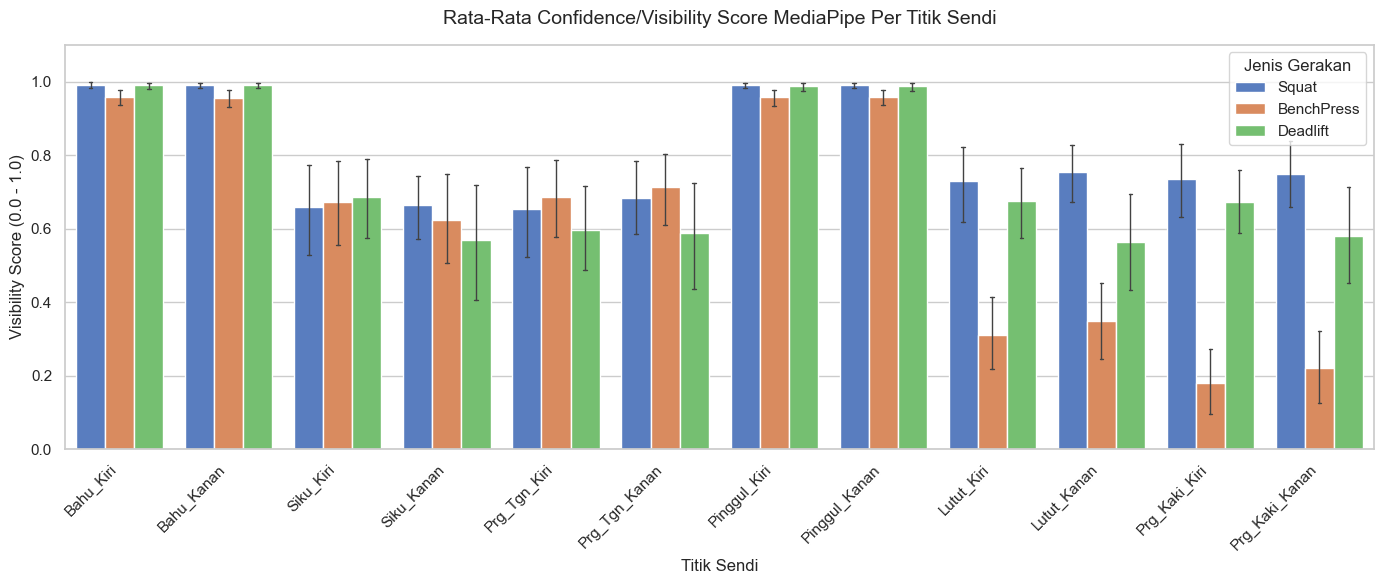

In [3]:
df_vis = pd.DataFrame(visibility_records)

plt.figure(figsize=(14, 6))
sns.barplot(
    data=df_vis, 
    x="Joint", 
    y="Mean_Visibility", 
    hue="Exercise", 
    capsize=.1, 
    errwidth=1
)
plt.title("Rata-Rata Confidence/Visibility Score MediaPipe Per Titik Sendi", fontsize=14, pad=15)
plt.ylabel("Visibility Score (0.0 - 1.0)")
plt.xlabel("Titik Sendi")
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1.1)
plt.legend(title="Jenis Gerakan")
plt.tight_layout()
plt.show()

## 3. Visualisasi 2: Bone Length Jitter (Inkonsistensi Ukuran Tulang)
Pada dunia nyata, ukuran paha atau lengan seseorang tidak berubah memanjang atau memendek. Jika variansi (Coefficient of Variation) nilainya tinggi, berarti deteksi kerangka MediaPipe tidak stabil (gemetar/jitter) pada bagian tubuh tersebut.

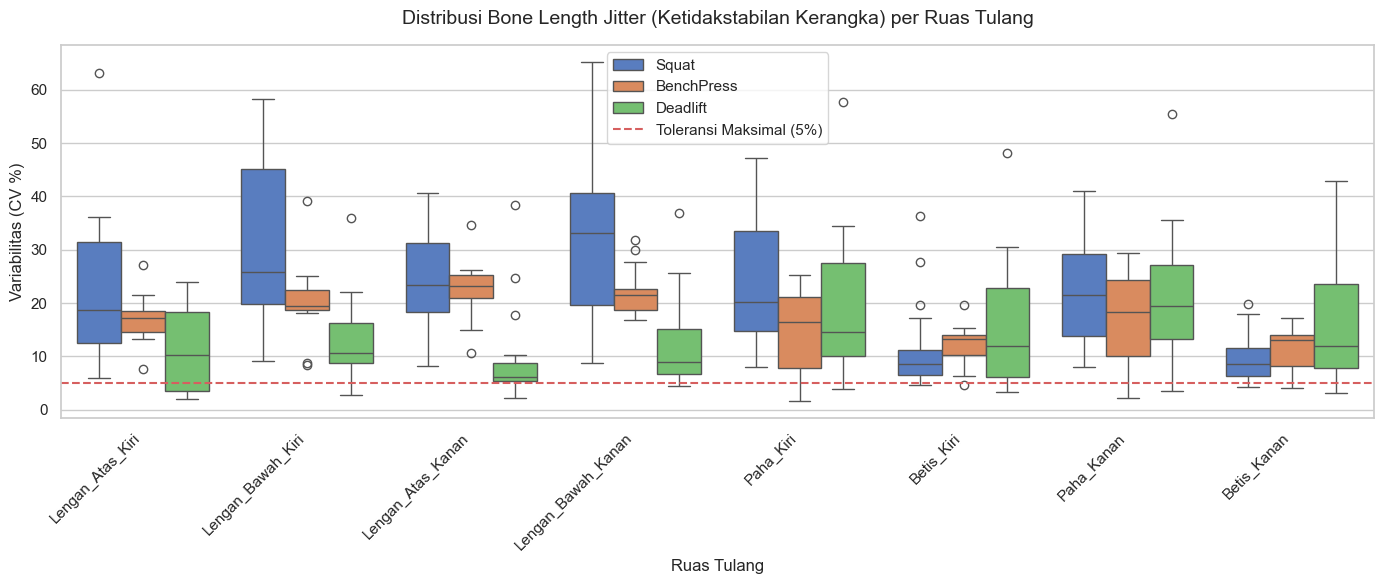

In [4]:
df_jitter = pd.DataFrame(jitter_records)

plt.figure(figsize=(14, 6))
sns.boxplot(
    data=df_jitter, 
    x="Bone", 
    y="Jitter_CV_Percent", 
    hue="Exercise"
)
plt.title("Distribusi Bone Length Jitter (Ketidakstabilan Kerangka) per Ruas Tulang", fontsize=14, pad=15)
plt.ylabel("Variabilitas (CV %)")
plt.xlabel("Ruas Tulang")
plt.xticks(rotation=45, ha='right')
# Beri garis batas toleransi ideal
plt.axhline(y=5, color='r', linestyle='--', label='Toleransi Maksimal (5%)')
plt.legend()
plt.tight_layout()
plt.show()